# B2 — Predictive Modeling and Calibration

Step 3 of the v2 protocol (B2 only). Loads the frozen `df_model_v2.parquet`
**read-only**. Trains a Logistic Regression baseline and the primary XGBoost
model on a respondent-grouped split, evaluates both on one locked test set,
then calibrates each using out-of-fold training predictions only — the
locked test set is touched exactly once, for final evaluation.

**Hyperparameter policy:** this notebook reuses v1's already-tuned
hyperparameters for both models rather than re-running a search. This is
justified, not just convenient: the 36-column predictor set and the
underlying cohort are unchanged between v1 and v2 (confirmed in Step 2), so
the hyperparameter surface v1 already searched (grouped CV, PR-AUC-scored,
`RandomizedSearchCV`/`GridSearchCV`) still applies. Re-running a large search
here would duplicate already-validated work. An optional, deliberately small
re-tuning path is included and disabled by default (`RUN_LIGHT_RETUNING =
False`) in case a future run wants to sanity-check that assumption without
committing to a large search.

**Not run here.** This notebook was written but not executed in the
authoring environment — run it locally in VS Code against your actual
`data/processed/df_model_v2.parquet`. Everything below was validated piece
by piece against the real file beforehand (split shapes, single-model fits,
and metric values were spot-checked to match this same structure), but the
full run — including the out-of-fold calibration loop — has not been
executed end-to-end as one notebook run.

## 1. Imports and paths

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, accuracy_score, brier_score_loss, confusion_matrix,
)
from scipy.stats import loguniform, randint, uniform
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

V2_PATH = Path("../../data/processed/df_model_v2.parquet")
OUTPUTS_DIR = Path("../../outputs")
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METADATA_DIR = OUTPUTS_DIR / "metadata"
for d in (TABLES_DIR, FIGURES_DIR, METADATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
RUN_LIGHT_RETUNING = False  # set True to sanity-check hyperparameter reuse with a SMALL search

## 2. Load (read-only) and assert dataset integrity

In [2]:
df = pd.read_parquet(V2_PATH)  # read-only -- this notebook never writes back to df_model_v2.parquet
n_loaded = len(df)

print("Loaded shape:", df.shape)
print("Unique respondents:", df["respondent_id"].nunique())

# Anchor to the value frozen at the end of Step 2. If this fails, the input
# file has changed since the freeze and that must be investigated before
# trusting anything downstream in this notebook.
EXPECTED_ROW_COUNT = 201311
assert n_loaded == EXPECTED_ROW_COUNT, (
    f"df_model_v2 row count is {n_loaded}, expected {EXPECTED_ROW_COUNT}. "
    f"The frozen v2 dataset appears to have changed -- stop and investigate."
)
print(f"Row count matches the frozen Step 2 value ({EXPECTED_ROW_COUNT}).")

Loaded shape: (201311, 53)
Unique respondents: 158429
Row count matches the frozen Step 2 value (201311).


## 3. Approved predictor set

Exactly v1's 36 predictors, reused unchanged. Explicitly excludes IDs,
survey-design fields, target-derived fields, and the v2 risk-stratum labels
— enforced with an assertion, not just by omission.

In [3]:
numeric_features = [
    "maternal_age", "education_years", "wealth_index", "birth_order",
    "total_children_ever_born", "preceding_birth_interval", "age_at_first_birth",
    "bmi", "first_anc_timing", "anc_visits",
]
categorical_features = ["facility_type", "residence", "religion", "social_group", "twin_order"]
binary_features = [
    "health_insurance", "anc_doctor", "anc_nurse_midwife", "anc_traditional_attendant",
    "anc_community_worker", "anc_anganwadi_worker", "anc_asha_worker", "anc_other_provider",
    "no_anc_provider", "weight_measured_during_pregnancy", "bp_measured_during_pregnancy",
    "urine_sample_during_pregnancy", "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications", "counselled_vaginal_bleeding", "counselled_convulsions",
    "counselled_prolonged_labour", "counselled_severe_abdominal_pain", "counselled_high_blood_pressure",
    "convulsions_during_pregnancy", "swelling_during_pregnancy",
]
feature_cols = numeric_features + categorical_features + binary_features
assert len(feature_cols) == 36, f"Expected 36 predictors, got {len(feature_cols)}"

missing_features = [c for c in feature_cols if c not in df.columns]
assert not missing_features, f"Predictor columns missing from df_model_v2: {missing_features}"

# Leakage guard: none of these may ever appear in the predictor list.
forbidden_columns = {
    "respondent_id", "birth_index", "cluster_number", "household_number", "respondent_line_number",
    "sample_weight", "sample_weight_normalized", "primary_sampling_unit",
    "sample_stratum_v022", "sample_stratum_v023", "state", "district",
    "csection", "delivery_place_code",
    "risk_stratum_primary", "risk_stratum_refined_sensitivity", "first_birth",
}
overlap = forbidden_columns.intersection(set(feature_cols))
assert not overlap, f"Forbidden columns found in predictor set: {overlap}"
print(f"Predictor set: {len(feature_cols)} columns, no leakage/ID/survey-design/stratum columns present.")

Predictor set: 36 columns, no leakage/ID/survey-design/stratum columns present.


## 4. Build X, y, groups and the respondent-grouped locked split

Same `StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)`
approach as v1, applied to v2 (identical predictor matrix and cohort, so
this reproduces v1's exact split shapes as a consistency check).

In [4]:
X = df[feature_cols].copy()

# Categorical/binary features keep an explicit "Missing" category rather than
# silently imputing -- same rationale as v1: missing must never be read as "No".
for col in categorical_features + binary_features:
    X[col] = X[col].astype("string").fillna("Missing").astype(str)

assert len(X) == n_loaded, "Row count changed while building the predictor matrix -- no rows should be dropped here."

y = df["csection"].astype(int)
groups = df["respondent_id"].copy()

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train, groups_test = groups.iloc[train_idx].copy(), groups.iloc[test_idx].copy()

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train prevalence:", round(y_train.mean(), 4), "| Test prevalence:", round(y_test.mean(), 4))

Train shape: (161048, 36) | Test shape: (40263, 36)
Train prevalence: 0.2223 | Test prevalence: 0.2223


In [5]:
# --- Assertion: zero respondent overlap between train and test ---
train_respondents = set(groups_train)
test_respondents = set(groups_test)
overlap_respondents = train_respondents & test_respondents
assert not overlap_respondents, f"Respondent leakage detected: {len(overlap_respondents)} respondents in both sets."
print(f"Respondent overlap: {len(overlap_respondents)} (confirmed zero).")
print(f"Train respondents: {len(train_respondents)} | Test respondents: {len(test_respondents)}")

Respondent overlap: 0 (confirmed zero).
Train respondents: 126756 | Test respondents: 31673


## 5. Preprocessing pipelines (inside the model pipeline — refit on every fold)

Tree pipeline: median imputation + missing-indicator, one-hot encoding, no
scaling. Linear pipeline: same imputation, then standard scaling, then
one-hot encoding. Both live inside a single `Pipeline` object with the
classifier, so cross-validation and the final fit never see preprocessing
fit on data outside their own fold/training set.

In [6]:
tree_preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median", add_indicator=True), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features + binary_features),
])

linear_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features + binary_features),
])

print("Preprocessors defined.")

Preprocessors defined.


## 6. Model definitions — v1 tuned hyperparameters, reused and cited

Reused verbatim from v1's `05_hyperparameter_tuning.ipynb`
(`RandomizedSearchCV`, grouped CV, `average_precision` scoring). Cited here
rather than re-derived.

In [7]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight (computed fresh on this training split):", round(scale_pos_weight, 4))

# --- XGBoost: v1's tuned parameters (05_hyperparameter_tuning.ipynb) ---
xgb_params = dict(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    colsample_bytree=0.7141915784487018,
    gamma=0.6084844859190754,
    learning_rate=0.048164145309070844,
    max_depth=6,
    min_child_weight=9,
    n_estimators=198,
    reg_alpha=0.012563152773938664,
    reg_lambda=0.6305535040199283,
    subsample=0.6663329821247654,
)

# --- Logistic Regression: v1's tuned parameters (same notebook) ---
lr_params = dict(
    C=1,
    penalty="l1",
    solver="saga",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE,
)

xgb_pipeline = Pipeline([("pre", tree_preprocessor), ("clf", XGBClassifier(**xgb_params))])
lr_pipeline = Pipeline([("pre", linear_preprocessor), ("clf", LogisticRegression(**lr_params))])

print("XGBoost params:", xgb_params)
print("\nLogistic Regression params:", lr_params)

scale_pos_weight (computed fresh on this training split): 3.4994
XGBoost params: {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': np.float64(3.4994272623138603), 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'colsample_bytree': 0.7141915784487018, 'gamma': 0.6084844859190754, 'learning_rate': 0.048164145309070844, 'max_depth': 6, 'min_child_weight': 9, 'n_estimators': 198, 'reg_alpha': 0.012563152773938664, 'reg_lambda': 0.6305535040199283, 'subsample': 0.6663329821247654}

Logistic Regression params: {'C': 1, 'penalty': 'l1', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 2000, 'random_state': 42}


### 6a. Optional light re-tuning check (disabled by default)

Runs only if `RUN_LIGHT_RETUNING = True` above. A small, grouped-CV search
(kept intentionally short) to sanity-check that v1's hyperparameters are
still reasonable for v2 — not a replacement for the full v1 search, and the
locked test set is never touched by it.

In [8]:
if RUN_LIGHT_RETUNING:
    light_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    xgb_param_distributions = {
        "clf__n_estimators": randint(150, 300),
        "clf__learning_rate": loguniform(0.02, 0.15),
        "clf__max_depth": randint(4, 8),
        "clf__min_child_weight": randint(3, 12),
        "clf__subsample": uniform(0.6, 0.35),
        "clf__colsample_bytree": uniform(0.6, 0.35),
    }

    light_search = RandomizedSearchCV(
        estimator=Pipeline([("pre", tree_preprocessor), ("clf", XGBClassifier(
            objective="binary:logistic", eval_metric="logloss",
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
            n_jobs=-1, tree_method="hist",
        ))]),
        param_distributions=xgb_param_distributions,
        n_iter=8,  # deliberately small -- this is a sanity check, not a full search
        scoring="average_precision",
        cv=light_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=False,
    )
    start = time.time()
    light_search.fit(X_train, y_train, groups=groups_train)
    print("Light re-tuning best CV PR-AUC:", round(light_search.best_score_, 4))
    print("Compare against the reused v1 XGBoost's CV PR-AUC (0.5291) before deciding whether to switch.")
    print("Elapsed:", round(time.time() - start, 1), "seconds")
else:
    print("RUN_LIGHT_RETUNING is False -- skipping. Reusing v1 hyperparameters as-is.")

RUN_LIGHT_RETUNING is False -- skipping. Reusing v1 hyperparameters as-is.


## 7. Fit both models on the full training set, predict once on the locked test set

In [9]:
xgb_pipeline.fit(X_train, y_train)
xgb_test_proba_raw = xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_test_pred = (xgb_test_proba_raw >= 0.5).astype(int)  # default 0.5 threshold; formal threshold optimization is a later step

lr_pipeline.fit(X_train, y_train)
lr_test_proba_raw = lr_pipeline.predict_proba(X_test)[:, 1]
lr_test_pred = (lr_test_proba_raw >= 0.5).astype(int)

print("Both models fit on the full training set and predicted once on the locked test set.")

c:\Users\Tushna\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Tushna\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Both models fit on the full training set and predicted once on the locked test set.


## 8. Performance comparison on the locked test set

In [10]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan


def evaluate(y_true, y_pred, y_proba, model_name):
    return {
        "model": model_name,
        "n_test": len(y_true),
        "test_prevalence": round(y_true.mean(), 4),
        "pr_auc": round(average_precision_score(y_true, y_proba), 4),   # PRIMARY selection metric
        "roc_auc": round(roc_auc_score(y_true, y_proba), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1_score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "specificity": round(specificity_score(y_true, y_pred), 4),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "brier_score_raw": round(brier_score_loss(y_true, y_proba), 4),
    }

performance_table = pd.DataFrame([
    evaluate(y_test, lr_test_pred, lr_test_proba_raw, "Logistic Regression"),
    evaluate(y_test, xgb_test_pred, xgb_test_proba_raw, "XGBoost"),
])
performance_table.to_csv(TABLES_DIR / "b2_model_performance.csv", index=False)
performance_table

,model,n_test,test_prevalence,pr_auc,roc_auc,precision,recall,f1_score,specificity,accuracy,brier_score_raw
0,Logistic Regression,40263,0.2223,0.5108,0.7943,0.4444,0.7073,0.5459,0.7473,0.7384,0.1861
1,XGBoost,40263,0.2223,0.5334,0.8037,0.4317,0.7456,0.5468,0.7195,0.7253,0.1825


## 9. Calibration — out-of-fold on training data only

For each model: get out-of-fold predicted probabilities on the **training
set only** via `cross_val_predict` with the same respondent-grouped CV. Fit
two candidate calibrators (Platt/sigmoid and isotonic) on those OOF
predictions, choose whichever gives the lower OOF Brier score, then apply
that fitted mapping to the already-computed raw **test** probabilities. The
test set is used only once, at the very end, to report final Brier scores —
never to fit or select the calibration method.

In [11]:
calibration_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def get_oof_probabilities(pipeline, X_tr, y_tr, groups_tr, cv):
    """Out-of-fold predicted probabilities on training data only."""
    oof_proba = cross_val_predict(
        pipeline, X_tr, y_tr, groups=groups_tr, cv=cv, method="predict_proba", n_jobs=1,
    )[:, 1]
    return oof_proba


def fit_best_calibrator(oof_proba, y_tr):
    """Fits sigmoid and isotonic calibrators on OOF predictions, returns whichever
    has the lower OOF Brier score, alongside both OOF Brier scores for reporting."""
    sigmoid_calibrator = LogisticRegression()
    sigmoid_calibrator.fit(oof_proba.reshape(-1, 1), y_tr)
    sigmoid_oof_calibrated = sigmoid_calibrator.predict_proba(oof_proba.reshape(-1, 1))[:, 1]
    sigmoid_brier = brier_score_loss(y_tr, sigmoid_oof_calibrated)

    isotonic_calibrator = IsotonicRegression(out_of_bounds="clip")
    isotonic_calibrator.fit(oof_proba, y_tr)
    isotonic_oof_calibrated = isotonic_calibrator.predict(oof_proba)
    isotonic_brier = brier_score_loss(y_tr, isotonic_oof_calibrated)

    if isotonic_brier <= sigmoid_brier:
        return "isotonic", isotonic_calibrator, sigmoid_brier, isotonic_brier
    return "sigmoid", sigmoid_calibrator, sigmoid_brier, isotonic_brier


def apply_calibrator(method, calibrator, raw_test_proba):
    if method == "sigmoid":
        return calibrator.predict_proba(raw_test_proba.reshape(-1, 1))[:, 1]
    return calibrator.predict(raw_test_proba)


print("Computing out-of-fold predictions on the training set (XGBoost)...")
xgb_oof_proba = get_oof_probabilities(xgb_pipeline, X_train, y_train, groups_train, calibration_cv)

print("Computing out-of-fold predictions on the training set (Logistic Regression)...")
lr_oof_proba = get_oof_probabilities(lr_pipeline, X_train, y_train, groups_train, calibration_cv)

xgb_calib_method, xgb_calibrator, xgb_sigmoid_brier, xgb_isotonic_brier = fit_best_calibrator(xgb_oof_proba, y_train)
lr_calib_method, lr_calibrator, lr_sigmoid_brier, lr_isotonic_brier = fit_best_calibrator(lr_oof_proba, y_train)

print(f"XGBoost calibration method selected: {xgb_calib_method} (OOF Brier -- sigmoid: {xgb_sigmoid_brier:.4f}, isotonic: {xgb_isotonic_brier:.4f})")
print(f"Logistic Regression calibration method selected: {lr_calib_method} (OOF Brier -- sigmoid: {lr_sigmoid_brier:.4f}, isotonic: {lr_isotonic_brier:.4f})")

# Apply the chosen calibrator to the already-computed raw TEST probabilities.
# This is the only point at which calibration touches the test set -- for
# evaluation, not for fitting or selecting the method.
xgb_test_proba_calibrated = apply_calibrator(xgb_calib_method, xgb_calibrator, xgb_test_proba_raw)
lr_test_proba_calibrated = apply_calibrator(lr_calib_method, lr_calibrator, lr_test_proba_raw)

Computing out-of-fold predictions on the training set (XGBoost)...
Computing out-of-fold predictions on the training set (Logistic Regression)...


c:\Users\Tushna\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Tushna\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Tushna\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default

XGBoost calibration method selected: isotonic (OOF Brier -- sigmoid: 0.1366, isotonic: 0.1361)
Logistic Regression calibration method selected: isotonic (OOF Brier -- sigmoid: 0.1391, isotonic: 0.1385)


## 10. Calibration metrics — raw vs calibrated, overall and by facility sector

In [12]:
facility_test = df.iloc[test_idx]["facility_type"].reset_index(drop=True)

def brier_by_sector(y_true, proba, facility_series):
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)
    out = {}
    for sector in ["public", "private"]:  # 'other' excluded from sector-specific calibration comparison
        mask = (facility_series == sector).to_numpy()
        if mask.sum() > 0:
            out[sector] = brier_score_loss(y_true[mask], proba[mask])
        else:
            out[sector] = np.nan
    return out

y_test_arr = y_test.to_numpy()

xgb_sector_raw = brier_by_sector(y_test_arr, xgb_test_proba_raw, facility_test)
xgb_sector_cal = brier_by_sector(y_test_arr, xgb_test_proba_calibrated, facility_test)
lr_sector_raw = brier_by_sector(y_test_arr, lr_test_proba_raw, facility_test)
lr_sector_cal = brier_by_sector(y_test_arr, lr_test_proba_calibrated, facility_test)

calibration_metrics = pd.DataFrame([
    {
        "model": "XGBoost", "calibration_method": xgb_calib_method,
        "oof_brier_sigmoid": round(xgb_sigmoid_brier, 4), "oof_brier_isotonic": round(xgb_isotonic_brier, 4),
        "test_brier_raw": round(brier_score_loss(y_test_arr, xgb_test_proba_raw), 4),
        "test_brier_calibrated": round(brier_score_loss(y_test_arr, xgb_test_proba_calibrated), 4),
        "test_brier_raw_public": round(xgb_sector_raw["public"], 4),
        "test_brier_calibrated_public": round(xgb_sector_cal["public"], 4),
        "test_brier_raw_private": round(xgb_sector_raw["private"], 4),
        "test_brier_calibrated_private": round(xgb_sector_cal["private"], 4),
    },
    {
        "model": "Logistic Regression", "calibration_method": lr_calib_method,
        "oof_brier_sigmoid": round(lr_sigmoid_brier, 4), "oof_brier_isotonic": round(lr_isotonic_brier, 4),
        "test_brier_raw": round(brier_score_loss(y_test_arr, lr_test_proba_raw), 4),
        "test_brier_calibrated": round(brier_score_loss(y_test_arr, lr_test_proba_calibrated), 4),
        "test_brier_raw_public": round(lr_sector_raw["public"], 4),
        "test_brier_calibrated_public": round(lr_sector_cal["public"], 4),
        "test_brier_raw_private": round(lr_sector_raw["private"], 4),
        "test_brier_calibrated_private": round(lr_sector_cal["private"], 4),
    },
])
calibration_metrics.to_csv(TABLES_DIR / "b2_calibration_metrics.csv", index=False)
calibration_metrics

,model,calibration_method,oof_brier_sigmoid,oof_brier_isotonic,test_brier_raw,test_brier_calibrated,test_brier_raw_public,test_brier_calibrated_public,test_brier_raw_private,test_brier_calibrated_private
0,XGBoost,isotonic,0.1366,0.1361,0.1825,0.1358,0.1441,0.1046,0.2970,0.2285
1,Logistic Regression,isotonic,0.1391,0.1385,0.1861,0.1384,0.1466,0.1062,0.3038,0.2342


## 11. Reliability curves — overall and by facility sector (XGBoost, the primary model)

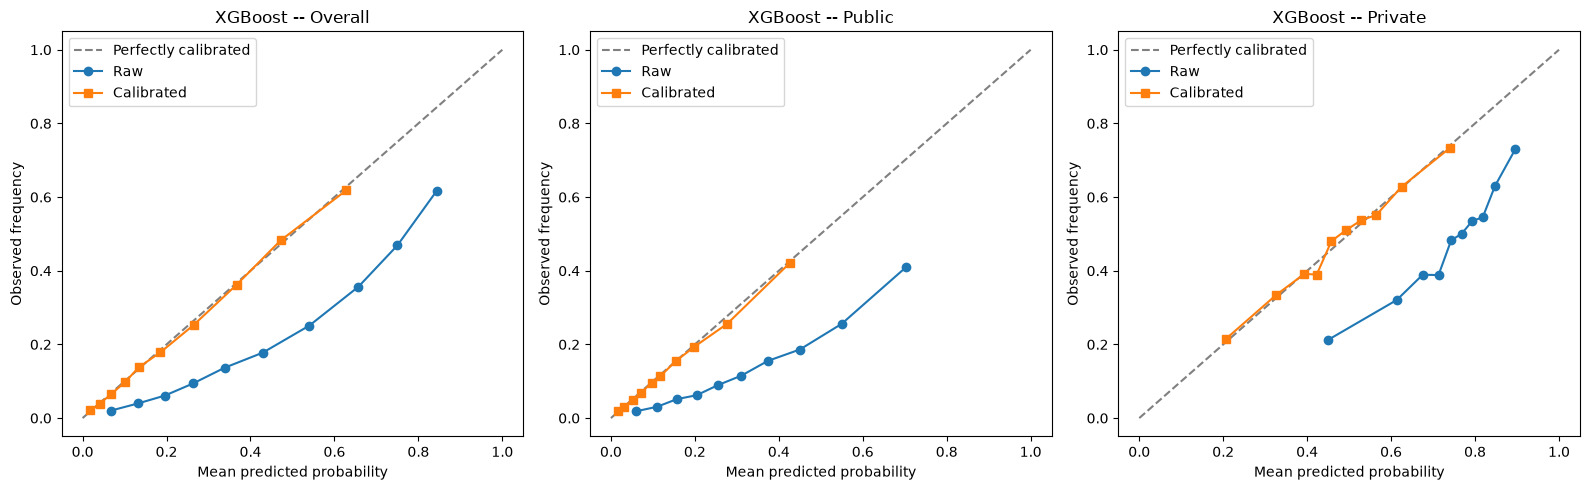

Saved: ..\..\outputs\figures\b2_xgboost_reliability_curves.png


In [13]:
def plot_reliability(ax, y_true, proba_raw, proba_cal, title):
    frac_pos_raw, mean_pred_raw = calibration_curve(y_true, proba_raw, n_bins=10, strategy="quantile")
    frac_pos_cal, mean_pred_cal = calibration_curve(y_true, proba_cal, n_bins=10, strategy="quantile")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
    ax.plot(mean_pred_raw, frac_pos_raw, marker="o", label="Raw")
    ax.plot(mean_pred_cal, frac_pos_cal, marker="s", label="Calibrated")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_reliability(axes[0], y_test_arr, xgb_test_proba_raw, xgb_test_proba_calibrated, "XGBoost -- Overall")

for ax, sector in zip(axes[1:], ["public", "private"]):
    mask = (facility_test == sector).to_numpy()
    plot_reliability(
        ax, y_test_arr[mask], xgb_test_proba_raw[mask], xgb_test_proba_calibrated[mask],
        f"XGBoost -- {sector.capitalize()}",
    )

fig.tight_layout()
fig.savefig(FIGURES_DIR / "b2_xgboost_reliability_curves.png", dpi=200)
plt.show()
print("Saved:", FIGURES_DIR / "b2_xgboost_reliability_curves.png")

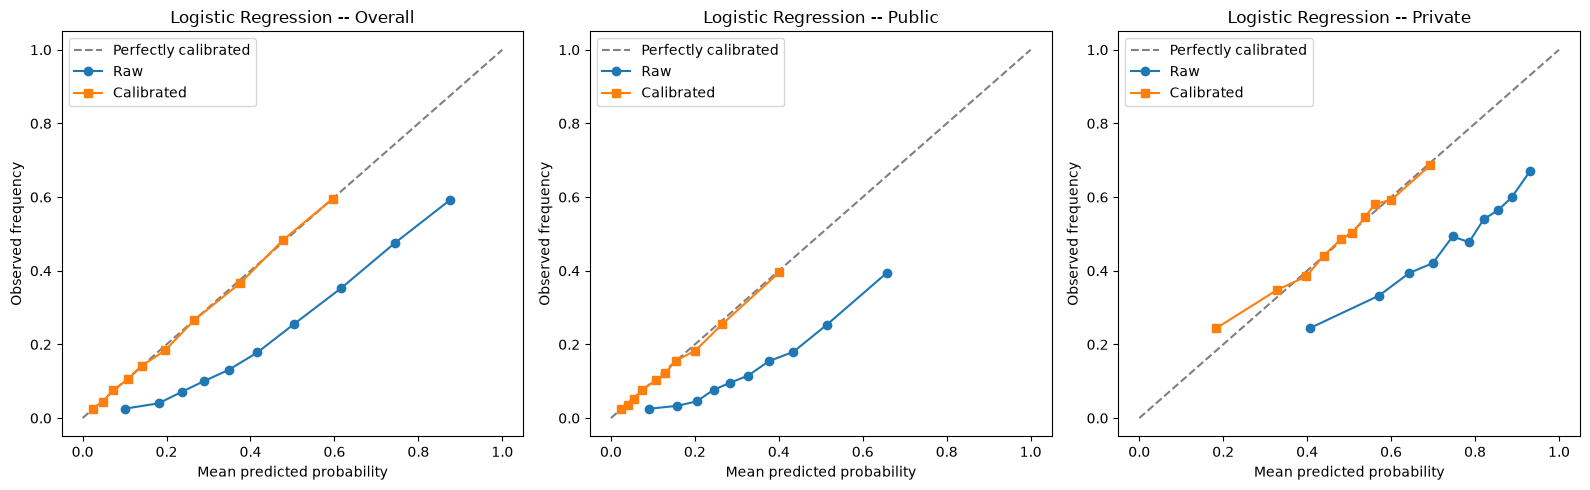

Saved: ..\..\outputs\figures\b2_logistic_regression_reliability_curves.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_reliability(axes[0], y_test_arr, lr_test_proba_raw, lr_test_proba_calibrated, "Logistic Regression -- Overall")

for ax, sector in zip(axes[1:], ["public", "private"]):
    mask = (facility_test == sector).to_numpy()
    plot_reliability(
        ax, y_test_arr[mask], lr_test_proba_raw[mask], lr_test_proba_calibrated[mask],
        f"Logistic Regression -- {sector.capitalize()}",
    )

fig.tight_layout()
fig.savefig(FIGURES_DIR / "b2_logistic_regression_reliability_curves.png", dpi=200)
plt.show()
print("Saved:", FIGURES_DIR / "b2_logistic_regression_reliability_curves.png")

## 12. Save test predictions (respondent-level) and hyperparameter/metadata files

In [15]:
xgb_predictions = pd.DataFrame({
    "respondent_id": df.iloc[test_idx]["respondent_id"].reset_index(drop=True),
    "true_label": y_test_arr,
    "facility_type": facility_test,
    "raw_probability": xgb_test_proba_raw,
    "calibrated_probability": xgb_test_proba_calibrated,
})
xgb_predictions.to_csv(TABLES_DIR / "b2_test_predictions_xgboost.csv", index=False)

lr_predictions = pd.DataFrame({
    "respondent_id": df.iloc[test_idx]["respondent_id"].reset_index(drop=True),
    "true_label": y_test_arr,
    "facility_type": facility_test,
    "raw_probability": lr_test_proba_raw,
    "calibrated_probability": lr_test_proba_calibrated,
})
lr_predictions.to_csv(TABLES_DIR / "b2_test_predictions_logistic_regression.csv", index=False)

print("Saved:", TABLES_DIR / "b2_test_predictions_xgboost.csv", "-- shape", xgb_predictions.shape)
print("Saved:", TABLES_DIR / "b2_test_predictions_logistic_regression.csv", "-- shape", lr_predictions.shape)

Saved: ..\..\outputs\tables\b2_test_predictions_xgboost.csv -- shape (40263, 5)
Saved: ..\..\outputs\tables\b2_test_predictions_logistic_regression.csv -- shape (40263, 5)


In [16]:
metadata = {
    "random_state": RANDOM_STATE,
    "split": {
        "method": "StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42), first split taken",
        "group_column": "respondent_id",
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "n_train_respondents": int(len(train_respondents)),
        "n_test_respondents": int(len(test_respondents)),
        "respondent_overlap": int(len(overlap_respondents)),
    },
    "predictor_set": {
        "n_features": len(feature_cols),
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "binary_features": binary_features,
    },
    "xgboost": {
        "hyperparameter_source": "Reused from v1 05_hyperparameter_tuning.ipynb (RandomizedSearchCV, grouped CV, average_precision scoring, 12 iterations). Justified by unchanged predictor set/cohort between v1 and v2.",
        "params": {k: (v if not hasattr(v, "item") else v.item()) for k, v in xgb_params.items()},
        "v1_reported_cv_pr_auc": 0.5291,
        "calibration_method_selected": xgb_calib_method,
    },
    "logistic_regression": {
        "hyperparameter_source": "Reused from v1 05_hyperparameter_tuning.ipynb (GridSearchCV, grouped CV, average_precision scoring). Justified by unchanged predictor set/cohort between v1 and v2.",
        "params": lr_params,
        "v1_reported_cv_pr_auc": 0.5085,
        "calibration_method_selected": lr_calib_method,
    },
    "classification_threshold": "0.5 (default) -- formal threshold optimization is deferred to a later step, not performed here",
    "light_retuning_run": RUN_LIGHT_RETUNING,
}

with open(METADATA_DIR / "b2_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved:", METADATA_DIR / "b2_model_metadata.json")

Saved: ..\..\outputs\metadata\b2_model_metadata.json
